# 02. 사후 판정 모델 (Patch Verdict)

**Patch Verdict — 요루 패치 정당성 분석**

이 노트북에서 하는 것:
1. 판정 기준 정의 (축 1: 패치 정당성 / 축 2: 현재 강도)
2. 패치별 피처 벡터 구성 및 점수 계산
3. 케이스 분석 — 패치 12.05 너프 / 패치 5.01 리워크
4. VCT 산티아고 보조 분석
5. 종합 시각화 및 결과 저장

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.3f}'.format)

DATA_DIR = './'
df  = pd.read_csv(DATA_DIR + 'yoru_processed.csv')
vct = pd.read_csv(DATA_DIR + 'vct_santiago_2026_clean.csv')

ACT_ORDER = [
    'E6A3','E7A1','E7A2','E7A3','E8A1','E8A2','E8A3',
    'E9A1','E9A2','E9A3','E10A1','E10A2','E10A3',
    'E11A1','E11A2','E11A3','E12A1','V26A2'
]
df['act_idx']  = df['act'].map({a: i for i, a in enumerate(ACT_ORDER)})
df['low_sample'] = df['matches'] < 50000
df = df.sort_values('act_idx').reset_index(drop=True)
print('로드 완료:', df.shape)

로드 완료: (18, 36)


## 1. 판정 기준 정의

### 축 1 — 패치 정당성 (0~100점)
```
76~100  BALANCED    — 의도한 방향으로 정확히 조정
51~75   EFFECTIVE   — 방향은 맞지만 강도가 다소 강하거나 약함
26~50   EXCESSIVE   — 강도가 지나쳐 메타 왜곡
0~25    INEFFECTIVE — 유의미한 영향 없음
```

### 축 2 — 현재 강도
```
STILL OP   — 너프 이후에도 지배적 (승률 51%+)
STRONG     — 강하지만 이전보다 약해짐 (49~51%)
BALANCED   — 평균 수준 (47~49%)
WEAKENED   — 평균 이하 (45~47%)
NEEDS BUFF — 버프 시급 (45% 미만)
PENDING    — 샘플 부족, 판정 보류
```

### 채점 구성 (너프 기준)
| 항목 | 배점 | 기준 |
|---|---|---|
| A. 픽률 반응 | 30점 | 너프 전 픽률 초과분 + 너프 후 평균 수렴도 |
| B. 승률 반응 | 20점 | 너프 전 승률이 구간 베이스라인 대비 얼마나 높았나 |
| C. 경쟁 요원 반사이익 | 25점 | 동일 포지션 요원 픽률 상승 여부 |
| D. 강도 적절성 | 25점 | 픽률 변화율이 적정 범위(20~60%)인가 |

In [2]:
# ── 축 2 판정 ──────────────────────────────────────────
def current_state(wr, low_sample):
    if low_sample:    return 'PENDING'
    if wr >= 51.0:    return 'STILL_OP'
    elif wr >= 49.0:  return 'STRONG'
    elif wr >= 47.0:  return 'BALANCED'
    elif wr >= 45.0:  return 'WEAKENED'
    else:             return 'NEEDS_BUFF'

df['current_state'] = df.apply(
    lambda r: current_state(r['win_rate'], r['low_sample']), axis=1
)
print(df[['act','era','win_rate','pick_rate_pct','current_state','low_sample']].to_string(index=False))

  act         era  win_rate  pick_rate_pct current_state  low_sample
 E6A3  pre_rework    48.210          0.960      BALANCED       False
 E7A1  pre_rework    48.390          1.010      BALANCED       False
 E7A2  pre_rework    48.480          1.470      BALANCED       False
 E7A3  pre_rework    48.930          1.170      BALANCED       False
 E8A1  pre_rework    48.410          1.390      BALANCED       False
 E8A2  pre_rework    48.620          1.320      BALANCED       False
 E8A3  pre_rework    48.300          1.250      BALANCED       False
 E9A1  pre_rework    48.530          1.200      BALANCED       False
 E9A2  pre_rework    48.470          1.340      BALANCED       False
 E9A3  pre_rework    49.010          1.420        STRONG       False
E10A1 post_rework    49.370          2.150        STRONG       False
E10A2 post_rework    49.080          2.420        STRONG       False
E10A3 post_rework    48.880          2.370      BALANCED       False
E11A1 post_rework    48.650       

In [3]:
# ── 축 1 채점 함수 ──────────────────────────────────────
def compute_verdict_score(df, patch_act, direction, n_window=3, rival_agents=None):
    """
    patch_act  : 패치가 처음 반영된 액트 (예: 'V26A2')
    direction  : 'nerf' 또는 'buff'
    n_window   : 전후 비교에 사용할 액트 수
    rival_agents : 반사이익 확인할 경쟁 요원 리스트
    """
    idx = df[df['act'] == patch_act].index[0]
    pre = df.loc[max(0, idx - n_window): idx - 1]

    # post: low_sample이어도 포함하되 신뢰도 가중치(low_penalty) 적용
    post_all = df.loc[idx: idx + n_window - 1]
    post_ok  = post_all[~post_all['low_sample']]
    if post_ok.empty and not post_all.empty:
        post_for_calc = post_all
        low_penalty   = 0.5   # 초반 스냅샷 — 50% 신뢰도
    elif not post_ok.empty:
        post_for_calc = post_ok
        low_penalty   = 1.0
    else:
        return None, {}

    pre_wr   = pre['win_rate'].mean()
    pre_pr   = pre['pick_rate_pct'].mean()
    post_wr  = post_for_calc['win_rate'].mean()
    post_pr  = post_for_calc['pick_rate_pct'].mean()
    wr_delta = post_wr - pre_wr
    pr_delta = post_pr - pre_pr
    pr_pct   = pr_delta / pre_pr * 100 if pre_pr else 0

    details = {
        'pre_wr': round(pre_wr, 3),   'pre_pr': round(pre_pr, 3),
        'post_wr': round(post_wr, 3), 'post_pr': round(post_pr, 3),
        'wr_delta': round(wr_delta, 3),
        'pr_delta': round(pr_delta, 3),
        'pr_pct_chg': round(pr_pct, 2),
        'low_penalty': low_penalty,
    }

    # A. 픽률 반응 (30점)
    # 다이아+ 에이전트 평균 픽률 기준 2.5% (25명 균등 4%에서 메타 쏠림 보정)
    AVG_PR = 2.5
    if direction == 'nerf':
        pr_excess    = max(0, pre_pr - AVG_PR)
        score_A_pre  = min(15, pr_excess / AVG_PR * 15)
        # 수렴도: post_pr이 AVG_PR ±1% 이내면 이상적
        conv = max(0, 1 - max(0, abs(post_pr - AVG_PR) - 1.0) / max(pre_pr - AVG_PR, 0.01))
        score_A_post = min(15, conv * 15) * low_penalty
    else:
        pr_deficit   = max(0, AVG_PR - pre_pr)
        score_A_pre  = min(15, pr_deficit / AVG_PR * 15)
        score_A_post = min(15, max(0, pr_delta / AVG_PR * 15)) * low_penalty
    score_A = score_A_pre + score_A_post
    details.update({'score_A_pickrate': round(score_A, 2),
                    'score_A_pre': round(score_A_pre, 2),
                    'score_A_post': round(score_A_post, 2)})

    # B. 승률 반응 (20점)
    # 베이스라인: 리워크 이전 구간 평균 승률 (구조적 하한선)
    ERA_WR_BASE = df[df['era'] == 'pre_rework']['win_rate'].mean()
    if direction == 'nerf':
        score_B = min(20, max(0, pre_wr - ERA_WR_BASE) / 0.5 * 20)
    else:
        score_B = min(20, max(0, ERA_WR_BASE - pre_wr) / 0.5 * 20)
    score_B *= low_penalty
    details.update({'score_B_winrate': round(score_B, 2),
                    'era_wr_baseline': round(ERA_WR_BASE, 3)})

    # C. 경쟁 요원 반사이익 (25점)
    score_C = 0
    rival_details = {}
    if rival_agents:
        for agent in rival_agents:
            col = f'pick_rate_pct_{agent}'
            if col not in df.columns: continue
            pre_r  = pre[col].mean()
            post_r = post_for_calc[col].mean()
            if np.isnan(pre_r) or np.isnan(post_r): continue
            rd = post_r - pre_r
            if direction == 'nerf':
                ag_sc = min(12.5, max(0, rd / 0.5 * 12.5))  # 0.5%p 상승시 만점
            else:
                ag_sc = min(12.5, max(0, -rd / 0.5 * 12.5))
            ag_sc *= low_penalty
            score_C += ag_sc
            rival_details[agent] = {
                'pre': round(pre_r,3), 'post': round(post_r,3),
                'delta': round(rd,3),  'score': round(ag_sc,2)
            }
        score_C = min(25, score_C)
    details.update({'score_C_rival': round(score_C, 2),
                    'rival_details': rival_details})

    # D. 강도 적절성 (25점)
    # 적정 범위: 픽률 20~60% 변화
    # 80% 초과 하락(또는 상승)이면 0점
    mag = -pr_pct if direction == 'nerf' else pr_pct
    if   mag >= 20 and mag <= 60: score_D = 25.0
    elif mag < 20:                score_D = mag / 20 * 25
    else:                         score_D = max(0, 25 - (mag - 60) / 30 * 25)
    score_D *= low_penalty
    details.update({'score_D_intensity': round(score_D, 2),
                    'pr_mag_pct': round(mag, 2)})

    total = min(100, max(0, score_A + score_B + score_C + score_D))
    details['total_score'] = round(total, 1)
    return total, details


def score_to_label(s):
    if s >= 76:  return 'BALANCED'
    elif s >= 51: return 'EFFECTIVE'
    elif s >= 26: return 'EXCESSIVE'
    else:         return 'INEFFECTIVE'


print('채점 함수 정의 완료')

채점 함수 정의 완료


## 2. 패치 12.05 너프 판정

In [4]:
score, details = compute_verdict_score(
    df, patch_act='V26A2', direction='nerf',
    n_window=3, rival_agents=['KAYO','Skye']
)
label = score_to_label(score)
state = df[df['act']=='V26A2'].iloc[0]['current_state']

print('=' * 55)
print('패치 12.05 너프 — 요루')
print('=' * 55)
print(f'\n[축 1 — 패치 정당성]')
print(f'  총점: {score:.1f} / 100  →  {label}')
print(f'  A. 픽률 반응:    {details["score_A_pickrate"]:.1f} / 30')
print(f'     패치전 초과:  {details["score_A_pre"]:.1f}  |  수렴도: {details["score_A_post"]:.1f}')
print(f'  B. 승률 반응:    {details["score_B_winrate"]:.1f} / 20')
print(f'     베이스라인:   {details["era_wr_baseline"]:.2f}%  |  패치전: {details["pre_wr"]:.2f}%')
print(f'  C. 경쟁 요원:    {details["score_C_rival"]:.1f} / 25')
print(f'  D. 강도 적절성:  {details["score_D_intensity"]:.1f} / 25')
print(f'     픽률 변화폭:  {details["pr_mag_pct"]:.1f}%  (적정: 20~60%)')
if details['low_penalty'] < 1.0:
    print(f'  ⚠  전 항목 {int(details["low_penalty"]*100)}% 신뢰도 적용 (V26A2 초반 스냅샷)')

print(f'\n[패치 전후]')
print(f'  픽률: {details["pre_pr"]:.2f}% → {details["post_pr"]:.2f}%  ({details["pr_pct_chg"]:+.1f}%)')
print(f'  승률: {details["pre_wr"]:.2f}% → {details["post_wr"]:.2f}%  ({details["wr_delta"]:+.3f}%p)')

print(f'\n[경쟁 요원 반사이익]')
for agent, d in details['rival_details'].items():
    sign = '+' if d['delta'] >= 0 else ''
    print(f'  {agent:<8}: {d["pre"]:.2f}% → {d["post"]:.2f}%  ({sign}{d["delta"]:.3f}%p)  [{d["score"]:.1f}점]')

print(f'\n[축 2 — 현재 강도]')
print(f'  판정: {state}')
v26 = df[df['act']=='V26A2'].iloc[0]
print(f'  승률: {v26["win_rate"]:.2f}%  픽률: {v26["pick_rate_pct"]:.2f}%  매치: {int(v26["matches"]):,}판')
if state == 'PENDING':
    print(f'  ⚠  샘플 부족 — VCT Stage 1 이후 재판정 필요')

SUMMARIES = {
    ('EXCESSIVE',  'PENDING'):  '너프 강도가 과했다. 아직 데이터 부족 — 지켜봐야 한다.',
    ('EXCESSIVE',  'WEAKENED'): '너프가 과했다. 지금 요루는 힘들다.',
    ('EXCESSIVE',  'BALANCED'): '너프가 과했지만, 아직 쓸 만한 수준은 유지하고 있다.',
    ('EFFECTIVE',  'WEAKENED'): '패치 방향은 맞았지만 강도가 약간 셌다.',
    ('EFFECTIVE',  'BALANCED'): '패치가 효과적으로 작동했다.',
    ('BALANCED',   'BALANCED'): '의도한 대로 정확히 잡혔다.',
    ('INEFFECTIVE','STRONG'):   '패치가 유의미한 변화를 만들지 못했다.',
}
summary = SUMMARIES.get((label, state), f'{label} + {state}')
print(f'\n→ {summary}')
print('=' * 55)

패치 12.05 너프 — 요루

[축 1 — 패치 정당성]
  총점: 26.8 / 100  →  EXCESSIVE
  A. 픽률 반응:    8.4 / 30
     패치전 초과:  6.4  |  수렴도: 2.0
  B. 승률 반응:    8.0 / 20
     베이스라인:   48.53%  |  패치전: 48.94%
  C. 경쟁 요원:    6.2 / 25
  D. 강도 적절성:  4.1 / 25
     픽률 변화폭:  80.1%  (적정: 20~60%)
  ⚠  전 항목 50% 신뢰도 적용 (V26A2 초반 스냅샷)

[패치 전후]
  픽률: 3.57% → 0.71%  (-80.1%)
  승률: 48.94% → 48.21%  (-0.727%p)

[경쟁 요원 반사이익]
  KAYO    : 1.02% → 0.75%  (-0.270%p)  [0.0점]
  Skye    : 2.70% → 4.22%  (+1.517%p)  [6.2점]

[축 2 — 현재 강도]
  판정: PENDING
  승률: 48.21%  픽률: 0.71%  매치: 18,940판
  ⚠  샘플 부족 — VCT Stage 1 이후 재판정 필요

→ 너프 강도가 과했다. 아직 데이터 부족 — 지켜봐야 한다.


## 3. 패치 5.01 리워크 판정 (비교 기준)

In [5]:
# 리워크는 '픽률 상승을 의도한 변화'로 buff 방향 적용
# rival 데이터가 E10A1부터 시작하므로 C 점수는 0 (참고용)
score_rw, details_rw = compute_verdict_score(
    df, patch_act='E10A1', direction='buff',
    n_window=3, rival_agents=['KAYO','Skye']
)
label_rw = score_to_label(score_rw)
state_rw = df[df['act']=='E10A1'].iloc[0]['current_state']

print('=' * 55)
print('패치 5.01 리워크 — 요루')
print('=' * 55)
print(f'총점: {score_rw:.1f} / 100  →  {label_rw}')
print(f'A. 픽률 반응:    {details_rw["score_A_pickrate"]:.1f} / 30')
print(f'B. 승률 반응:    {details_rw["score_B_winrate"]:.1f} / 20')
print(f'C. 경쟁 요원:    {details_rw["score_C_rival"]:.1f} / 25  (E10A1 rival 데이터 없음)')
print(f'D. 강도 적절성:  {details_rw["score_D_intensity"]:.1f} / 25')
print(f'픽률: {details_rw["pre_pr"]:.2f}% → {details_rw["post_pr"]:.2f}%  ({details_rw["pr_pct_chg"]:+.1f}%)')
print(f'승률: {details_rw["pre_wr"]:.2f}% → {details_rw["post_wr"]:.2f}%  ({details_rw["wr_delta"]:+.3f}%p)')
print('=' * 55)

패치 5.01 리워크 — 요루
총점: 25.3 / 100  →  INEFFECTIVE
A. 픽률 반응:    13.0 / 30
B. 승률 반응:    0.0 / 20
C. 경쟁 요원:    0.0 / 25  (E10A1 rival 데이터 없음)
D. 강도 적절성:  12.3 / 25
픽률: 1.32% → 2.31%  (+75.2%)
승률: 48.67% → 49.11%  (+0.440%p)


## 4. VCT 산티아고 보조 분석

In [6]:
total_maps = vct[['match_id','map']].drop_duplicates().shape[0]

# 에이전트별 픽 집계 (팀당 기준: total_maps × 2팀)
ag_picks = (
    vct.assign(ag=vct['agent'].str.split('/')).explode('ag')
       .groupby('ag')
       .agg(picks=('ag','count'), wins=('result', lambda x: (x=='win').sum()))
       .reset_index()
)
ag_picks['pick_rate'] = (ag_picks['picks'] / (total_maps * 2) * 100).round(1)
ag_picks['win_rate']  = (ag_picks['wins']  / ag_picks['picks'] * 100).round(1)
ag_picks = ag_picks.sort_values('picks', ascending=False).reset_index(drop=True)

print(f'[VCT 산티아고 에이전트 픽 (상위 15) / 총 {total_maps}맵]')
print(ag_picks.head(15).rename(columns={'ag':'agent'}).to_string(index=False))

print('\n[플래시 척후대 비교]')
flash = ag_picks[ag_picks['ag'].isin(['Yoru','Skye','KAYO','Phoenix'])]
print(flash.rename(columns={'ag':'agent'}).to_string(index=False))

# 팀별 요루 픽
yoru_vct = vct[vct['agent'].str.contains('Yoru', na=False)]
print('\n[팀별 요루 픽]')
team_yoru = (
    yoru_vct.groupby(['team','player'])
            .agg(picks=('agent','count'), wins=('result', lambda x: (x=='win').sum()))
            .reset_index().sort_values('picks', ascending=False)
)
team_yoru['win_rate'] = (team_yoru['wins'] / team_yoru['picks'] * 100).round(1)
print(team_yoru.to_string(index=False))

# 맵별 요루 픽
print('\n[맵별 요루 픽]')
map_yoru = (
    yoru_vct.groupby('map')
            .agg(picks=('agent','count'), wins=('result', lambda x: (x=='win').sum()))
            .reset_index().sort_values('picks', ascending=False)
)
map_yoru['win_rate'] = (map_yoru['wins'] / map_yoru['picks'] * 100).round(1)
print(map_yoru.to_string(index=False))

[VCT 산티아고 에이전트 픽 (상위 15) / 총 59맵]
  agent  picks  wins  pick_rate  win_rate
  Viper     73    36     61.900    49.300
   Yoru     73    39     61.900    53.400
   Omen     66    35     55.900    53.000
   Sova     59    28     50.000    47.500
   Neon     53    27     44.900    50.900
   Fade     45    28     38.100    62.200
  Astra     45    20     38.100    44.400
 Waylay     43    21     36.400    48.800
   Raze     16     8     13.600    50.000
   Skye     15     3     12.700    20.000
Killjoy     15     8     12.700    53.300
 Cypher     15     9     12.700    60.000
   Vyse     13     5     11.000    38.500
Chamber     11     6      9.300    54.500
Phoenix      9     5      7.600    55.600

[플래시 척후대 비교]
  agent  picks  wins  pick_rate  win_rate
   Yoru     73    39     61.900    53.400
   Skye     15     3     12.700    20.000
Phoenix      9     5      7.600    55.600

[팀별 요루 픽]
             team      player  picks  wins  win_rate
        Paper Rex   something     14     7    50

## 5. 종합 시각화

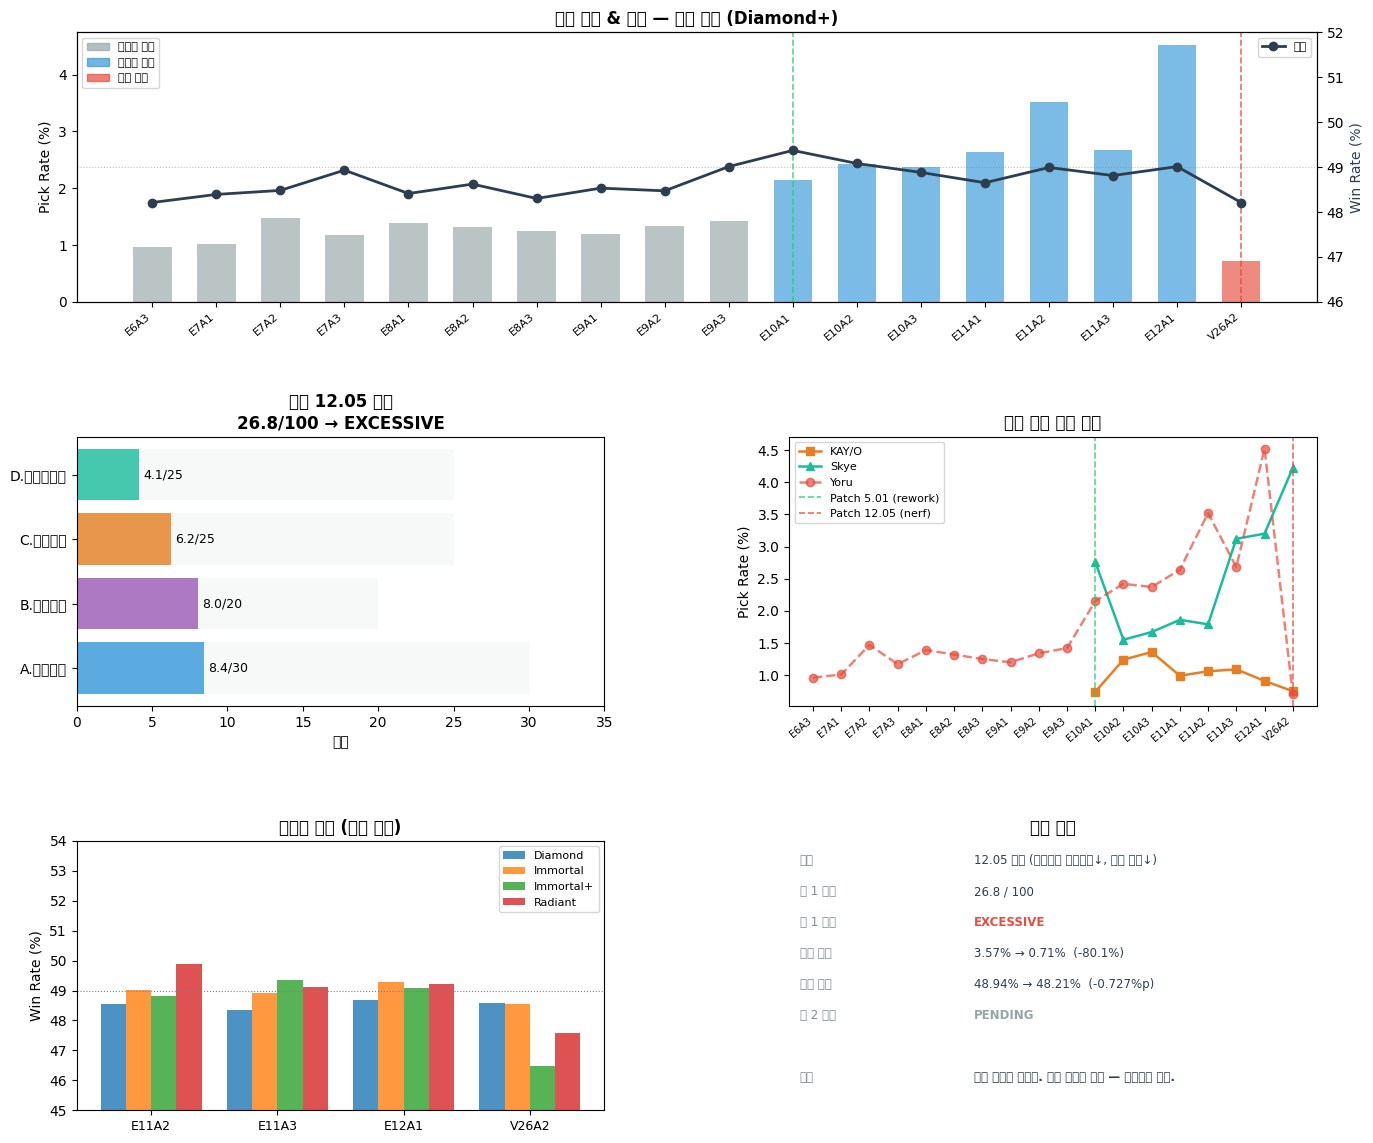

저장: yoru_verdict_12_05.png


In [7]:
fig = plt.figure(figsize=(16, 14))
gs  = fig.add_gridspec(3, 2, hspace=0.5, wspace=0.35)
ax1 = fig.add_subplot(gs[0, :])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[1, 1])
ax4 = fig.add_subplot(gs[2, 0])
ax5 = fig.add_subplot(gs[2, 1])

COLORS = {'pre_rework':'#95a5a6','post_rework':'#3498db','post_nerf':'#e74c3c'}
ERA_KR  = {'pre_rework':'리워크 이전','post_rework':'리워크 이후','post_nerf':'너프 이후'}

x = df['act_idx']

def patch_vlines(ax):
    ax.axvline(ACT_ORDER.index('E10A1'), color='#2ecc71', ls='--', lw=1.2, alpha=0.8, label='Patch 5.01 (rework)')
    ax.axvline(ACT_ORDER.index('V26A2'), color='#e74c3c', ls='--', lw=1.2, alpha=0.8, label='Patch 12.05 (nerf)')

# ax1: 픽률 막대 + 승률 꺾은선
ax1b = ax1.twinx()
ax1.bar(x, df['pick_rate_pct'], color=[COLORS[e] for e in df['era']], alpha=0.65, width=0.6)
ax1b.plot(x, df['win_rate'], marker='o', color='#2c3e50', lw=2, zorder=5, label='승률')
ax1b.axhline(49.0, color='gray', ls=':', lw=0.8, alpha=0.5)
ax1b.set_ylim(46, 52)
ax1b.set_ylabel('Win Rate (%)', color='#2c3e50')
ax1.set_ylabel('Pick Rate (%)')
ax1.set_title('요루 픽률 & 승률 — 전체 액트 (Diamond+)', fontweight='bold')
patch_vlines(ax1)
ax1.set_xticks(range(len(ACT_ORDER)))
ax1.set_xticklabels(ACT_ORDER, rotation=40, ha='right', fontsize=8)
legend_p = [mpatches.Patch(color=v, label=ERA_KR[k], alpha=0.7) for k,v in COLORS.items()]
ax1.legend(handles=legend_p, loc='upper left', fontsize=8)
ax1b.legend(loc='upper right', fontsize=8)

# ax2: 12.05 판정 점수 게이지
cats   = ['A.픽률반응', 'B.승률반응', 'C.반사이익', 'D.강도적절성']
scores = [details['score_A_pickrate'], details['score_B_winrate'],
          details['score_C_rival'],    details['score_D_intensity']]
maxes  = [30, 20, 25, 25]
bcolors = ['#3498db','#9b59b6','#e67e22','#1abc9c']
b2 = ax2.barh(cats, scores, color=bcolors, alpha=0.8)
ax2.barh(cats, maxes, color='#ecf0f1', alpha=0.4, zorder=0)
for bar, s, m in zip(b2, scores, maxes):
    ax2.text(s + 0.3, bar.get_y() + bar.get_height()/2,
             f'{s:.1f}/{m}', va='center', fontsize=9)
ax2.set_xlim(0, 35)
ax2.set_title(f'패치 12.05 너프\n{score:.1f}/100 → {label}', fontweight='bold')
ax2.set_xlabel('점수')

# ax3: 경쟁 요원 픽률 추이
rv = df[df['pick_rate_pct_KAYO'].notna()]
ax3.plot(rv['act_idx'], rv['pick_rate_pct_KAYO'], marker='s', color='#e67e22', lw=1.8, label='KAY/O')
ax3.plot(rv['act_idx'], rv['pick_rate_pct_Skye'], marker='^', color='#1abc9c', lw=1.8, label='Skye')
ax3.plot(x, df['pick_rate_pct'], marker='o', color='#e74c3c', lw=1.8, ls='--', label='Yoru', alpha=0.7)
patch_vlines(ax3)
ax3.set_xticks(range(len(ACT_ORDER)))
ax3.set_xticklabels(ACT_ORDER, rotation=40, ha='right', fontsize=7)
ax3.set_ylabel('Pick Rate (%)')
ax3.set_title('경쟁 요원 픽률 추이', fontweight='bold')
ax3.legend(fontsize=8)

# ax4: 티어별 승률 (너프 전후 4액트)
tier_sub = df[df['act'].isin(['E11A2','E11A3','E12A1','V26A2'])].copy()
tier_map = {'wr_diamond':'Diamond','wr_immortal':'Immortal',
            'wr_immortal2':'Immortal+','wr_radiant':'Radiant'}
width = 0.2
x4 = range(len(tier_sub))
for i, (col, lbl) in enumerate(tier_map.items()):
    ax4.bar([xi + i*width for xi in x4], tier_sub[col].values, width=width, label=lbl, alpha=0.8)
ax4.axhline(49.0, color='gray', ls=':', lw=0.8)
ax4.set_xticks([xi + 1.5*width for xi in x4])
ax4.set_xticklabels(tier_sub['act'].values, fontsize=9)
ax4.set_ylabel('Win Rate (%)')
ax4.set_ylim(45, 54)
ax4.set_title('티어별 승률 (너프 전후)', fontweight='bold')
ax4.legend(fontsize=8)

# ax5: 판정 요약 텍스트
ax5.axis('off')
ax5.set_title('판정 요약', fontweight='bold')
VCOL = {'BALANCED':'#27ae60','EFFECTIVE':'#f39c12','EXCESSIVE':'#e74c3c','INEFFECTIVE':'#95a5a6'}
SCOL = {'STILL_OP':'#e74c3c','STRONG':'#e67e22','BALANCED':'#27ae60',
        'WEAKENED':'#3498db','NEEDS_BUFF':'#9b59b6','PENDING':'#95a5a6'}
lines = [
    ('패치',       '12.05 너프 (관문충돌 지속시간↓, 기습 충전↓)'),
    ('축 1 점수',  f'{score:.1f} / 100'),
    ('축 1 판정',  label),
    ('픽률 변화',  f'{details["pre_pr"]:.2f}% → {details["post_pr"]:.2f}%  ({details["pr_pct_chg"]:+.1f}%)'),
    ('승률 변화',  f'{details["pre_wr"]:.2f}% → {details["post_wr"]:.2f}%  ({details["wr_delta"]:+.3f}%p)'),
    ('축 2 강도',  state),
    ('',           ''),
    ('결론',       summary),
]
for i, (k, v) in enumerate(lines):
    y = 0.95 - i * 0.115
    ax5.text(0.02, y, k, transform=ax5.transAxes, fontsize=8.5,
             color='#7f8c8d', va='top')
    color = '#2c3e50'
    if k == '축 1 판정': color = VCOL.get(v, color)
    if k == '축 2 강도': color = SCOL.get(v, color)
    fw = 'bold' if k in ('축 1 판정','축 2 강도','결론') else 'normal'
    ax5.text(0.35, y, v, transform=ax5.transAxes, fontsize=8.5,
             color=color, fontweight=fw, va='top')

plt.savefig('yoru_verdict_12_05.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: yoru_verdict_12_05.png')

## 6. 판정 결과 저장

In [8]:
result = pd.DataFrame([{
    'patch':         '12.05',
    'act':           'V26A2',
    'direction':     'nerf',
    'verdict_score': score,
    'verdict_label': label,
    'score_A':       details['score_A_pickrate'],
    'score_B':       details['score_B_winrate'],
    'score_C':       details['score_C_rival'],
    'score_D':       details['score_D_intensity'],
    'pre_wr':        details['pre_wr'],
    'post_wr':       details['post_wr'],
    'wr_delta':      details['wr_delta'],
    'pre_pr':        details['pre_pr'],
    'post_pr':       details['post_pr'],
    'pr_pct_chg':    details['pr_pct_chg'],
    'current_state': state,
    'low_sample':    True,
    'summary':       summary,
}])

result.to_csv('yoru_verdict_result.csv', index=False, encoding='utf-8-sig')
print('저장 완료: yoru_verdict_result.csv')
print(result.T.to_string(header=False))

저장 완료: yoru_verdict_result.csv
patch                                     12.05
act                                       V26A2
direction                                  nerf
verdict_score                            26.815
verdict_label                         EXCESSIVE
score_A                                   8.420
score_B                                   8.030
score_C                                   6.250
score_D                                   4.110
pre_wr                                   48.937
post_wr                                  48.210
wr_delta                                 -0.727
pre_pr                                    3.573
post_pr                                   0.710
pr_pct_chg                              -80.130
current_state                           PENDING
low_sample                                 True
summary        너프 강도가 과했다. 아직 데이터 부족 — 지켜봐야 한다.
